In [1]:
import pandas as pd
import numpy as np
import re

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from sentence_transformers import SentenceTransformer

In [2]:
df = pd.read_csv(
    "potential-talents - Aspiring human resources - seeking human resources.csv"
)

print("Shape:", df.shape)
df.head()

Shape: (104, 5)


,id,job_title,location,connection,fit
0,1,2019 C.T. Bauer College of Business Graduate (...,"Houston, Texas",85,NaN
1,2,Native English Teacher at EPIK (English Progra...,Kanada,500+,NaN
2,3,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,NaN
3,4,People Development Coordinator at Ryan,"Denton, Texas",500+,NaN
4,5,Advisory Board Member at Celal Bayar University,"İzmir, Türkiye",500+,NaN


In [3]:
df = df.drop_duplicates(
    subset=df.columns.drop("id")
).reset_index(drop=True)

In [4]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z ]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

def clean_connection(x):
    x = str(x)
    if "500+" in x:
        return 500
    return int(x)

df["job_title"] = df["job_title"].apply(clean_text)
df["connection"] = df["connection"].apply(clean_connection)

In [5]:
keywords = "aspiring human resources seeking human resources"

In [6]:
tfidf = TfidfVectorizer(stop_words="english")

tfidf_matrix = tfidf.fit_transform(df["job_title"])

keyword_vec = tfidf.transform([keywords])

In [7]:
df["tfidf_similarity"] = cosine_similarity(
    tfidf_matrix,
    keyword_vec
).flatten()

In [8]:
df["connection_score"] = df["connection"] / df["connection"].max()

df["tfidf_score"] = (
    0.85 * df["tfidf_similarity"] +
    0.15 * df["connection_score"]
)

In [9]:
model = SentenceTransformer("all-MiniLM-L6-v2")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [10]:
job_embeddings = model.encode(df["job_title"].tolist())

keyword_embedding = model.encode([keywords])

In [11]:
df["sbert_similarity"] = cosine_similarity(
    job_embeddings,
    keyword_embedding
).flatten()

In [12]:
df["sbert_score"] = (
    0.85 * df["sbert_similarity"] +
    0.15 * df["connection_score"]
)

In [13]:
tfidf_ranked = df.sort_values(
    "tfidf_score",
    ascending=False
)[["id","job_title","tfidf_score"]]

print("TOP TF-IDF RESULTS:")
print(tfidf_ranked.head(10))

TOP TF-IDF RESULTS:
     id                                          job_title  tfidf_score
21   73  aspiring human resources manager seeking inter...     0.638270
13   28              seeking human resources opportunities     0.609943
12   27  aspiring human resources management student se...     0.607705
45   97              aspiring human resources professional     0.560932
2     3              aspiring human resources professional     0.552832
47   99                   seeking human resources position     0.507343
5     6                aspiring human resources specialist     0.484019
8    10  seeking human resources hris and generalist po...     0.467253
48  100  aspiring human resources manager graduating ma...     0.419539
22   74                       human resources professional     0.409155


In [14]:
sbert_ranked = df.sort_values(
    "sbert_score",
    ascending=False
)[["id","job_title","sbert_score"]]

print("\nTOP SBERT RESULTS:")
print(sbert_ranked.head(10))


TOP SBERT RESULTS:
     id                                          job_title  sbert_score
13   28              seeking human resources opportunities     0.825138
45   97              aspiring human resources professional     0.776519
8    10  seeking human resources hris and generalist po...     0.775874
2     3              aspiring human resources professional     0.768419
12   27  aspiring human resources management student se...     0.765223
15   67  human resources staffing and recruiting profes...     0.754549
5     6                aspiring human resources specialist     0.739872
47   99                   seeking human resources position     0.705039
30   82  aspiring human resources professional an energ...     0.663605
48  100  aspiring human resources manager graduating ma...     0.650450


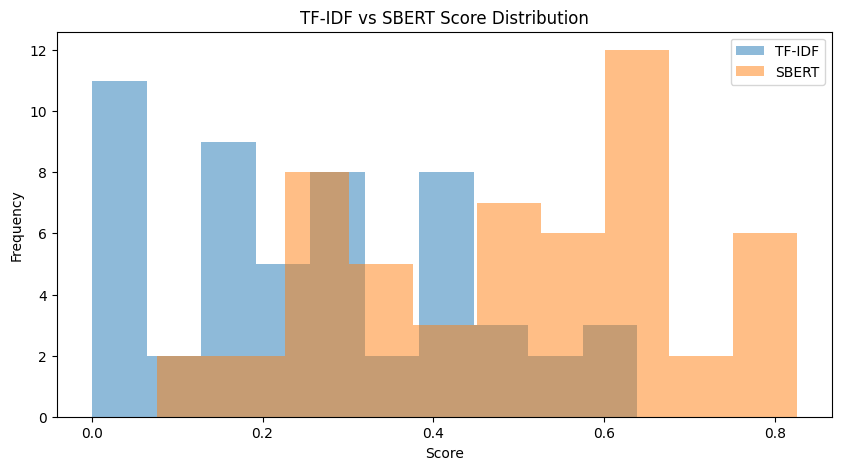

In [15]:
plt.figure(figsize=(10,5))

plt.hist(df["tfidf_score"], alpha=0.5, label="TF-IDF")
plt.hist(df["sbert_score"], alpha=0.5, label="SBERT")

plt.legend()
plt.title("TF-IDF vs SBERT Score Distribution")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()

In [16]:
print("Correlation between TF-IDF and SBERT scores:")

print(
    df[["tfidf_score","sbert_score"]].corr()
)

Correlation between TF-IDF and SBERT scores:
             tfidf_score  sbert_score
tfidf_score     1.000000     0.918172
sbert_score     0.918172     1.000000


In [17]:
comparison = pd.DataFrame({
    "Model": ["TF-IDF", "Sentence-BERT"],
    "Strength": [
        "Keyword-based, fast, interpretable",
        "Semantic understanding, context-aware"
    ],
    "Weakness": [
        "Fails on synonyms",
        "Slightly heavier computation"
    ]
})

print(comparison)

           Model                               Strength  \
0         TF-IDF     Keyword-based, fast, interpretable   
1  Sentence-BERT  Semantic understanding, context-aware   

                       Weakness  
0             Fails on synonyms  
1  Slightly heavier computation  
